In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [25]:
df = pd.read_csv("Mall_Customers.csv")

In [26]:
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [27]:
df.drop("CustomerID", axis=1, inplace=True)

In [28]:
df.rename(columns={"Genre": "Gender"}, inplace=True)

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Gender                  200 non-null    object
 1   Age                     200 non-null    int64 
 2   Annual Income (k$)      200 non-null    int64 
 3   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(3), object(1)
memory usage: 6.4+ KB


In [30]:
df.describe()

,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000
mean,38.850000,60.560000,50.200000
std,13.969007,26.264721,25.823522
min,18.000000,15.000000,1.000000
25%,28.750000,41.500000,34.750000
50%,36.000000,61.500000,50.000000
75%,49.000000,78.000000,73.000000
max,70.000000,137.000000,99.000000


In [31]:
import math

def plot_all_histograms(df: pd.DataFrame, title_prefix: str = ""):

    num_cols = df.select_dtypes(include=[np.number]).columns
    n_cols = 3
    n_rows = math.ceil(len(num_cols) / n_cols)

    plt.figure(figsize=(5 * n_cols, 4 * n_rows))

    for i , col in enumerate(num_cols, 1):
        plt.subplot(n_rows, n_cols, i)
        sns.histplot(df[col], bins=30, kde=True)
        plt.title(f"{title_prefix} {col}")
        plt.xlabel("")
        plt.ylabel("")

    plt.tight_layout()
    plt.show()

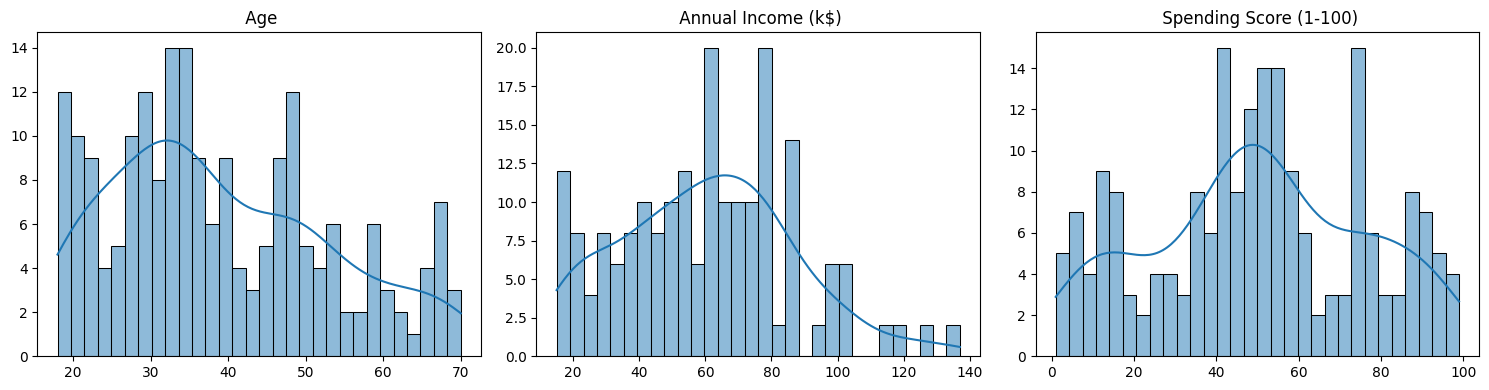

In [32]:
plot_all_histograms(df)

In [33]:
df["Gender"].value_counts()

Gender
Female    112
Male       88
Name: count, dtype: int64

In [34]:
from sklearn.preprocessing import LabelEncoder

In [35]:
le = LabelEncoder()

df["Gender"] = le.fit_transform(df["Gender"])

In [36]:
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40


In [37]:
from sklearn.preprocessing import MinMaxScaler

In [38]:
scaler = MinMaxScaler()
df_scaled = scaler.fit_transform(df)

In [40]:
df = pd.DataFrame(df_scaled, columns=df.columns)

In [41]:
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1.0,0.019231,0.000000,0.387755
1,1.0,0.057692,0.000000,0.816327
2,0.0,0.038462,0.008197,0.051020
3,0.0,0.096154,0.008197,0.775510
4,0.0,0.250000,0.016393,0.397959


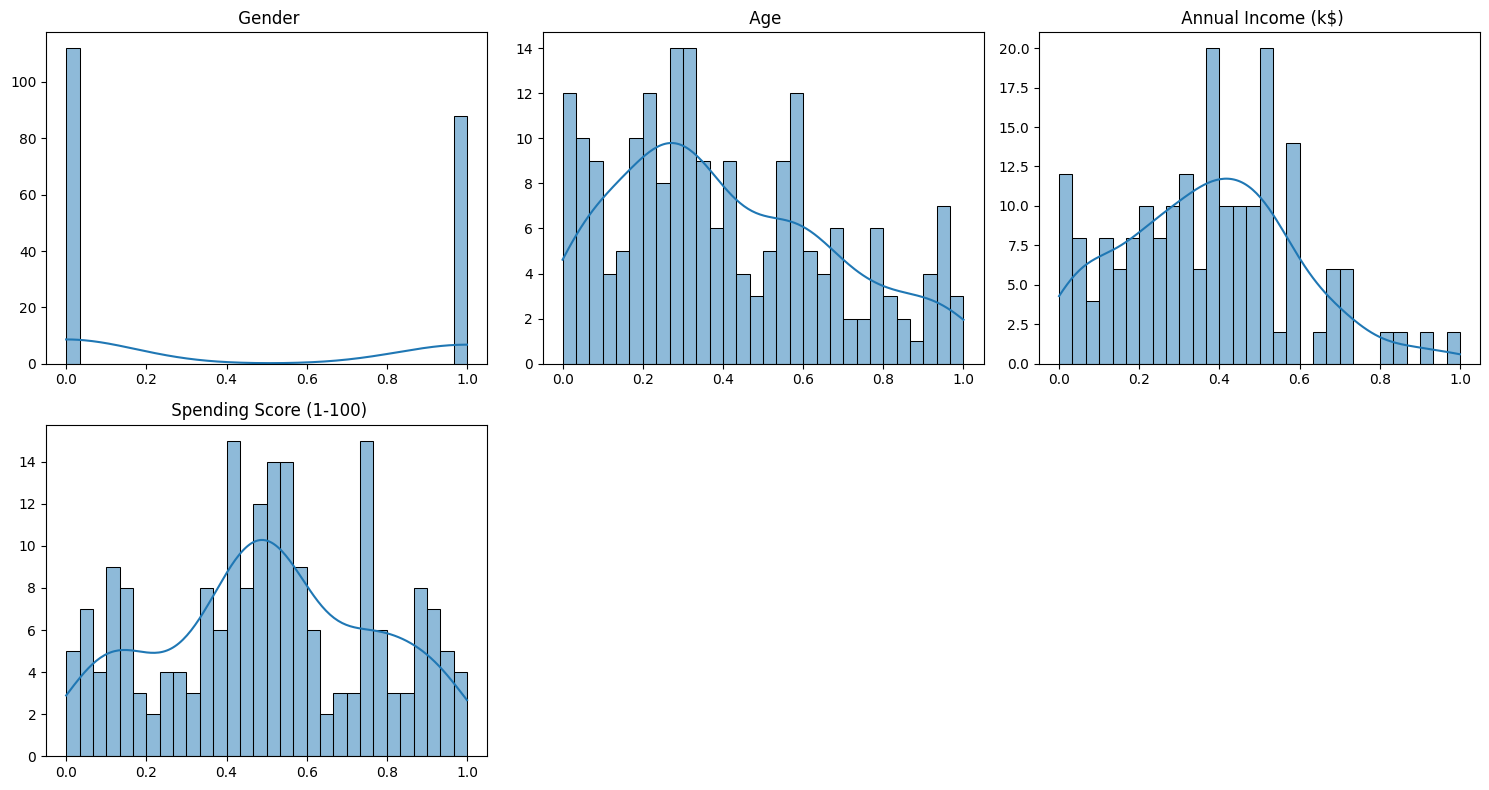

In [42]:
plot_all_histograms(df)

In [43]:
import scipy.cluster.hierarchy as sch

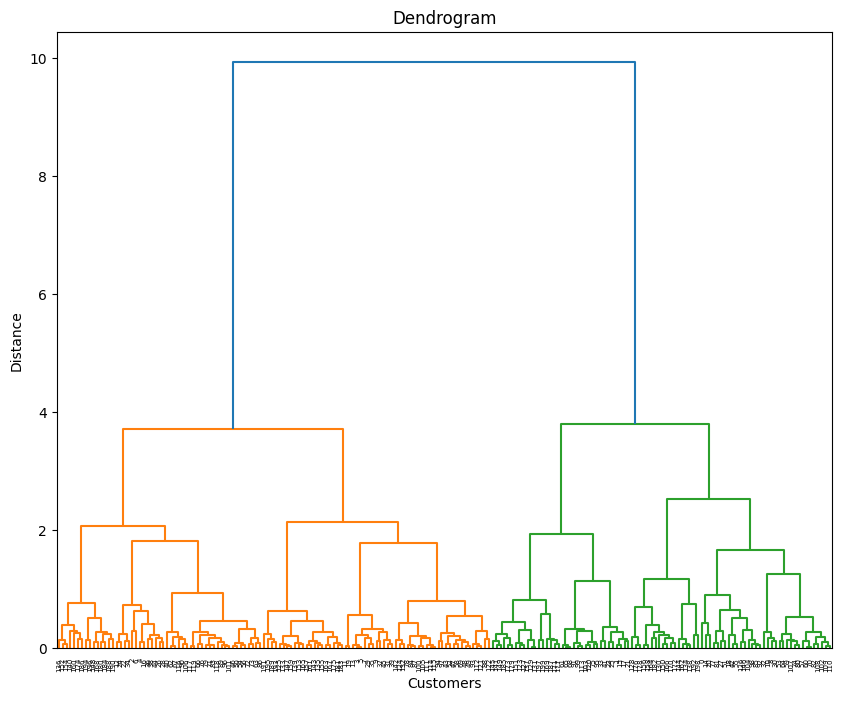

In [45]:
plt.figure(figsize=(10, 8))
plt.title("Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Distance")
dendrogram = sch.dendrogram(sch.linkage(df, method="ward"))
plt.show()

In [46]:
#4-6 Clusters. We will prefer 4 here.

In [47]:
from sklearn.cluster import AgglomerativeClustering

In [49]:
hc = AgglomerativeClustering(n_clusters=4)

In [50]:
y_hc = hc.fit_predict(df)

In [51]:
df["cluster"] = pd.DataFrame(y_hc)

In [52]:
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100),cluster
0,1.0,0.019231,0.000000,0.387755,0
1,1.0,0.057692,0.000000,0.816327,2
2,0.0,0.038462,0.008197,0.051020,3
3,0.0,0.096154,0.008197,0.775510,1
4,0.0,0.250000,0.016393,0.397959,3


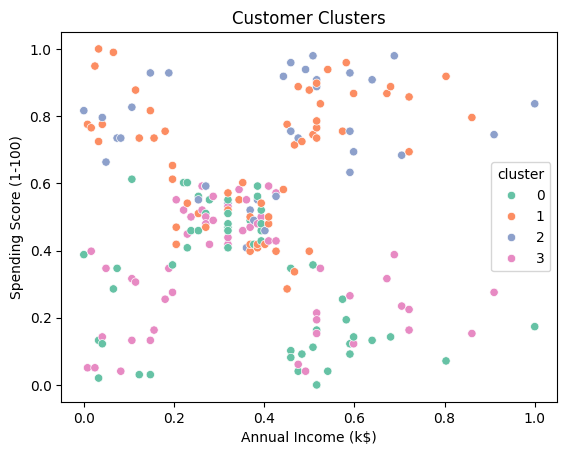

In [55]:
sns.scatterplot(data=df, x="Annual Income (k$)", y="Spending Score (1-100)", hue="cluster", palette="Set2")
plt.title("Customer Clusters")
plt.show()

In [56]:
from sklearn.metrics import silhouette_score
print(silhouette_score(df, y_hc))

0.7143503785893516


In [57]:
X = df[["Annual Income (k$)" ,"Spending Score (1-100)"]].copy()

In [58]:
X

,Annual Income (k$),Spending Score (1-100)
0,0.000000,0.387755
1,0.000000,0.816327
2,0.008197,0.051020
3,0.008197,0.775510
4,0.016393,0.397959
...,...,...
195,0.860656,0.795918
196,0.909836,0.275510
197,0.909836,0.744898
198,1.000000,0.173469


In [60]:
hc = AgglomerativeClustering(n_clusters=4)
y_hc = hc.fit_predict(X)
X["Cluster"] = pd.DataFrame(y_hc)

In [61]:
X.head()

,Annual Income (k$),Spending Score (1-100),Cluster
0,0.000000,0.387755,0
1,0.000000,0.816327,3
2,0.008197,0.051020,0
3,0.008197,0.775510,3
4,0.016393,0.397959,0


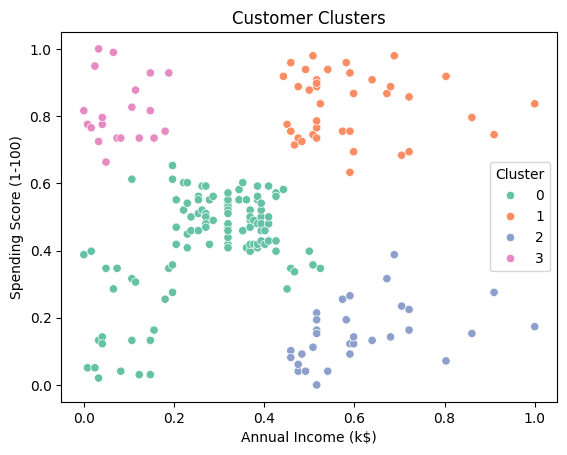

In [62]:
sns.scatterplot(data=X, x="Annual Income (k$)", y="Spending Score (1-100)", hue="Cluster", palette="Set2")
plt.title("Customer Clusters")
plt.show()

In [63]:
print(silhouette_score(X, y_hc))

0.8219082836375066


In [64]:
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score

In [65]:
df = pd.read_csv("Mall_Customers.csv")
df.drop("CustomerID", axis=1, inplace=True)
df.rename({"Genre": "Gender"}, axis=1, inplace=True)
le = LabelEncoder()
df["Gender"] = le.fit_transform(df["Gender"])
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40


In [66]:
features_2d = ["Annual Income (k$)", "Spending Score (1-100)"]
features_3d = ["Age", "Annual Income (k$)", "Spending Score (1-100)"]
features_4d = ["Gender", "Age", "Annual Income (k$)", "Spending Score (1-100)"]

In [74]:
for features in [features_2d, features_3d, features_4d]:
    X = df[features]
    X_scaled = MinMaxScaler().fit_transform(X)

    hc = AgglomerativeClustering(n_clusters=5, linkage="ward")
    y_hc = hc.fit_predict(X_scaled)

    silhouette = silhouette_score(X_scaled, y_hc)
    db_score = davies_bouldin_score(X_scaled, y_hc)
    ch_score = calinski_harabasz_score(X_scaled, y_hc)

    print(f"\nFeatures: {features}({len(features)})")
    print("\n--Scores--")
    print("Sil:", silhouette)
    print("DB:", db_score)
    print("CH:", ch_score)


Features: ['Annual Income (k$)', 'Spending Score (1-100)'](2)

--Scores--
Sil: 0.5582698727196419
DB: 0.5734519252471811
CH: 258.97400737720704

Features: ['Age', 'Annual Income (k$)', 'Spending Score (1-100)'](3)

--Scores--
Sil: 0.3955454334726547
DB: 0.8746143334035464
CH: 123.99070840826577

Features: ['Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)'](4)

--Scores--
Sil: 0.35032447507156306
DB: 1.0941951795238571
CH: 163.46602356383625


In [75]:
from sklearn.cluster import KMeans

In [76]:
for features in [features_2d, features_3d, features_4d]:
    X = df[features]
    X_scaled = MinMaxScaler().fit_transform(X)

    kmeans = KMeans(n_clusters=5)
    y_pred = kmeans.fit_predict(X_scaled)

    silhouette = silhouette_score(X_scaled, y_pred)
    db_score = davies_bouldin_score(X_scaled, y_pred)
    ch_score = calinski_harabasz_score(X_scaled, y_pred)

    print(f"\nFeatures: {features}({len(features)})")
    print("\n--Scores--")
    print("Sil:", silhouette)
    print("DB:", db_score)
    print("CH:", ch_score)


Features: ['Annual Income (k$)', 'Spending Score (1-100)'](2)

--Scores--
Sil: 0.5602436353739457
DB: 0.5630236200163117
CH: 264.70156956422267

Features: ['Age', 'Annual Income (k$)', 'Spending Score (1-100)'](3)

--Scores--
Sil: 0.40588120152587825
DB: 0.9361270042587131
CH: 126.05974459737251

Features: ['Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)'](4)

--Scores--
Sil: 0.3686063041181217
DB: 1.0440956761740572
CH: 164.50180144584226
